# Optimizing Movie Recommendations Using Genetic Algorithm

## Project Description

This project aims to optimize movie recommendations using a Genetic Algorithm (GA).
The MovieLens dataset is used to model user preferences and generate optimized
recommendation lists. Each chromosome represents a candidate movie recommendation
list, while the fitness function evaluates its quality based on multiple criteria.

**Tools Used**
- Python
- PyGAD
- Pandas
- NumPy
- Matplotlib

**Dataset**
- MovieLens (ml-latest-small)

# Import Required Libraries

In this step, all required Python libraries are imported.
These libraries are used for data manipulation, numerical computation,
visualization, and implementing the Genetic Algorithm.

In [115]:
import pandas as pd
import numpy as np
import pygad
import matplotlib.pyplot as plt

# Load the Dataset

The MovieLens dataset consists of two primary files:

- ratings.csv: User ratings for movies
- movies.csv: Movie information including title and genres

These files will be loaded into Pandas DataFrames.

In [116]:
ratings = pd.read_csv("./ml-latest-small/ratings.csv")
movies = pd.read_csv("./ml-latest-small/movies.csv")

# Explore the Dataset

Before preprocessing, it is useful to inspect the structure
of the dataset and understand its dimensions and contents.

In [117]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [118]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [119]:
ratings.shape

(100836, 4)

In [120]:
movies.shape

(9742, 3)

# Merge Movie Information with Ratings

The two datasets are merged using the **movieId**
column to create a unified dataset containing both
user ratings and movie metadata.

In [121]:
data = ratings.merge(movies, on="movieId")
genre_dict = dict(zip(movies["movieId"], movies["genres"]))

In [122]:
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Dataset Statistics

Basic statistics are computed to better understand
the scale of the recommendation problem, including:

- Number of users
- Number of movies
- Number of ratings
- Average rating

In [123]:
print("Users :", data["userId"].nunique())
print("Movies:", data["movieId"].nunique())
print("Ratings:", len(data))
print("Average Rating:", data["rating"].mean())

Users : 610
Movies: 9724
Ratings: 100836
Average Rating: 3.501556983616962


# Define Target User

In this step, we select a target user for whom we will generate optimized movie recommendations.
The Genetic Algorithm will learn preferences based on this user's past ratings.

In [124]:
target_user = 1

user_data = data[data["userId"] == target_user]
user_data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Define User Preference Profile

We define user preferences based on highly rated movies (rating ≥ 4).
These movies represent the user's favorite items and will be used to extract genre preferences.

In [125]:
favorite_movies = user_data[user_data["rating"] >= 4]

favorite_movies.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


# Build User Genre Profile

We extract genres from the user's favorite movies to build a preference profile.
This helps measure how well candidate movies match user interests.

In [126]:
from collections import Counter

genre_counter = Counter()

for mid in favorite_movies["movieId"]:
    genres = genre_dict[mid].split("|")
    genre_counter.update(genres)

genre_counter

Counter({'Action': 76,
         'Adventure': 74,
         'Comedy': 70,
         'Drama': 64,
         'Thriller': 43,
         'Fantasy': 41,
         'Crime': 39,
         'Children': 37,
         'Sci-Fi': 32,
         'Animation': 27,
         'Romance': 24,
         'War': 20,
         'Musical': 20,
         'Mystery': 13,
         'Horror': 9,
         'Western': 6,
         'Film-Noir': 1})

# Normalize Genre Profile

We convert raw genre counts into normalized preferences.

In [127]:
total = sum(genre_counter.values())

user_genre_profile = {
    genre: count / total
    for genre, count in genre_counter.items()
}

user_genre_profile

{'Adventure': 0.12416107382550336,
 'Animation': 0.04530201342281879,
 'Children': 0.06208053691275168,
 'Comedy': 0.1174496644295302,
 'Fantasy': 0.06879194630872483,
 'Romance': 0.040268456375838924,
 'Action': 0.12751677852348994,
 'Crime': 0.06543624161073826,
 'Thriller': 0.07214765100671142,
 'Mystery': 0.02181208053691275,
 'Drama': 0.10738255033557047,
 'War': 0.03355704697986577,
 'Western': 0.010067114093959731,
 'Sci-Fi': 0.053691275167785234,
 'Horror': 0.015100671140939598,
 'Musical': 0.03355704697986577,
 'Film-Noir': 0.0016778523489932886}

# Candidate Movies Pool

We remove movies already seen by the user.
Only unseen movies are used for optimization.

In [128]:
seen_movies = set(user_data["movieId"])
all_movies = set(movies["movieId"])

candidate_movies = list(all_movies - seen_movies)

movie_ids = np.array(candidate_movies)
movie_id_to_idx = {mid: i for i, mid in enumerate(movie_ids)}
idx_to_movie_id = {i: mid for mid, i in movie_id_to_idx.items()}

In [129]:
user_profile = dict(zip(user_data["movieId"], user_data["rating"]))

# Fitness Function (Preference + Genre Similarity)

The fitness function evaluates each recommendation list using:

1. User Preference Similarity
2. Genre Similarity

In [130]:
def genre_similarity(movie_id):
    genres = genre_dict[movie_id].split("|")
    
    score = 0
    for g in genres:
        if g in user_genre_profile:
            score += user_genre_profile[g]
    
    return score


def fitness_func(ga_instance, solution, solution_idx):
    preference_score = 0
    genre_score = 0
    
    for gene in solution:
        movie_id = idx_to_movie_id[gene]
        
        # Preference similarity (based on past ratings)
        if movie_id in user_profile:
            preference_score += user_profile[movie_id]
        
        # Genre similarity
        genre_score += genre_similarity(movie_id)
    
    preference_score /= len(solution)
    genre_score /= len(solution)
    
    fitness = 0.7 * preference_score + 0.3 * genre_score
    
    return fitness

# Genetic Algorithm Setup

In [131]:
num_genes = 10
gene_space = list(range(len(movie_ids)))

ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=5,
    fitness_func=fitness_func,
    sol_per_pop=20,
    num_genes=num_genes,
    gene_space=gene_space,
    parent_selection_type="tournament",
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=20
)

# Run Genetic Algorithm

In [132]:
ga_instance.run()

# Best Solution

In [133]:
solution, fitness, _ = ga_instance.best_solution()

recommended_movie_ids = [idx_to_movie_id[g] for g in solution]

print("Best Fitness:", fitness)
recommended_movie_ids

Best Fitness: 0.12120805369127519


[26340, 970, 151695, 136864, 116738, 26236, 43558, 5076, 103042, 40339]

# Show Recommended Movies

In [134]:
movies[movies["movieId"].isin(recommended_movie_ids)]

,movieId,title,genres
743,970,Beat the Devil (1953),Adventure|Comedy|Crime|Drama|Romance
3686,5076,"Adventures of Huck Finn, The (1993)",Adventure|Children|Comedy|Drama
5476,26236,"White Sun of the Desert, The (Beloe solntse pu...",Action|Adventure|Comedy|Drama|Romance|War
5490,26340,"Twelve Tasks of Asterix, The (Les douze travau...",Action|Adventure|Animation|Children|Comedy|Fan...
6047,40339,Chicken Little (2005),Action|Adventure|Animation|Children|Comedy|Sci-Fi
6126,43558,Big Momma's House 2 (2006),Action|Comedy|Crime
8183,103042,Man of Steel (2013),Action|Adventure|Fantasy|Sci-Fi|IMAX
8568,116738,DeadHeads (2011),Adventure|Comedy|Horror
8963,136864,Batman v Superman: Dawn of Justice (2016),Action|Adventure|Fantasy|Sci-Fi
9209,151695,The Survivalist (2015),Drama|Sci-Fi|Thriller


# Fitness Evolution

We visualize how the Genetic Algorithm improves over generations.

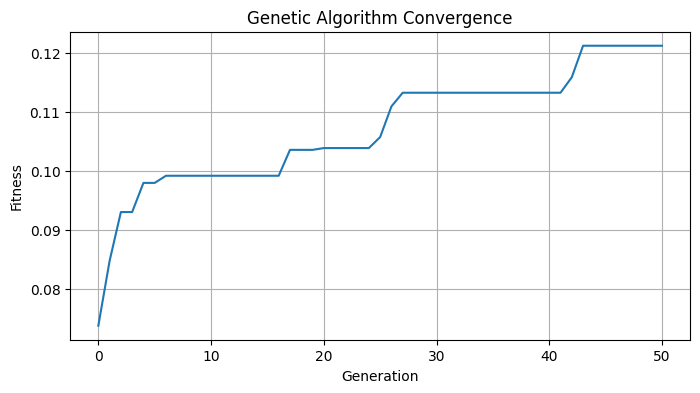

In [135]:
plt.figure(figsize=(8,4))
plt.plot(ga_instance.best_solutions_fitness)
plt.title("Genetic Algorithm Convergence")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.grid()
plt.show()